## Sales Analysis by Kodree

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from google.colab import drive

In [3]:
drive.mount('/content/drive')

df_products = pd.read_csv('/content/products.csv')
df_countries = pd.read_csv('/content/countries.csv')
df_events = pd.read_csv('/content/events.csv')

print("df_events    :", df_events.shape)
print("df_products  :", df_products.shape)
print("df_countries :", df_countries.shape)

Mounted at /content/drive
df_events    : (1330, 10)
df_products  : (12, 2)
df_countries : (249, 5)


## Merge tables

In [4]:

merge1 = pd.merge(df_events, df_products,
                  left_on='Product ID', right_on='id', how='left')

df_all = pd.merge(merge1, df_countries,
                  left_on='Country Code', right_on='alpha-3', how='left')

print("df_all shape :", df_all.shape)


df_all shape : (1330, 17)


## Data Cleaning

In [5]:
# 1. Convert date
df_all['Order Date'] = pd.to_datetime(df_all['Order Date'], dayfirst=False)
df_all['Ship Date'] = pd.to_datetime(df_all['Ship Date'], dayfirst=False)

# 2. Standardize text in  columns
df_all['Sales Channel'] = df_all['Sales Channel'].str.strip().str.title()
df_all['item_type'] = df_all['item_type'].str.strip().str.title()
df_all['name'] = df_all['name'].str.strip().str.title()
df_all['region'] = df_all['region'].str.strip().str.title()
df_all['sub-region'] = df_all['sub-region'].str.strip().str.title()

# 3. Replace Order Priority short codes
df_all['Order Priority'] = df_all['Order Priority'].str.strip()
df_all['Order Priority'] = df_all['Order Priority'].replace({
    'M': 'Medium', 'C': 'Critical',
    'L': 'Low', 'H': 'High'
})

# 4. Handle missing values
df_all['Country Code'] = df_all['Country Code'].fillna('UNK')
nan_cols = ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']
df_all[nan_cols] = df_all[nan_cols].fillna('Unknown')

# 5. Drop rows dengan Units Sold zero
df_all = df_all.dropna(subset=['Units Sold'])

# Check
print("Missing values after cleaning:")
print(df_all.isnull().sum())
print("\nShape :", df_all.shape)

Missing values after cleaning:
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
id                0
item_type         0
name              0
alpha-2           0
alpha-3           0
region            0
sub-region        0
dtype: int64

Shape : (1328, 17)


## Calculation new columns






In [7]:

df_all['Revenue'] = df_all['Unit Price'] * df_all['Units Sold']
df_all['Cost'] = df_all['Unit Cost'] * df_all['Units Sold']
df_all['Profit'] = df_all['Revenue'] - df_all['Cost']
df_all['day ship'] = (df_all['Ship Date'] - df_all['Order Date']).dt.days
df_all['Day of Week'] = df_all['Order Date'].dt.day_name()
df_all['Month Name'] = df_all['Order Date'].dt.month_name()
df_all['Month Period'] = df_all['Order Date'].dt.to_period('M').astype(str)

print(df_all[['Revenue', 'Cost', 'Profit', 'day ship']].head())

      Revenue        Cost     Profit  day ship
0   133705.00    76121.50   57583.50        10
1   409960.10   233400.23  176559.87         0
2  3136191.11  2358420.22  777770.89        24
3   127966.88    41968.64   85998.24        31
4   362897.60   243129.92  119767.68        38


## Key Metrics

In [8]:

print(f"  Total Orders    : {df_all['Order ID'].nunique():,}")
print(f"  Total Revenue   : ${df_all['Revenue'].sum():,.2f}")
print(f"  Total Profit    : ${df_all['Profit'].sum():,.2f}")
print(f"  Total Countries : {df_all['name'].nunique()}")
print(f"  Total Categories: {df_all['item_type'].nunique()}")
print(f"  Sales Channels  : {df_all['Sales Channel'].unique()}")
print(f"  Avg Ship Days   : {df_all['day ship'].mean():.2f} days")
print(f"  Date Range      : {df_all['Order Date'].min().date()} "
      f"to {df_all['Order Date'].max().date()}")


  Total Orders    : 1,328
  Total Revenue   : $1,702,129,408.21
  Total Profit    : $501,434,459.00
  Total Countries : 46
  Total Categories: 12
  Sales Channels  : ['Online' 'Offline']
  Avg Ship Days   : 24.79 days
  Date Range      : 2010-01-01 to 2017-07-23


###Chart 1 - Profit by Category

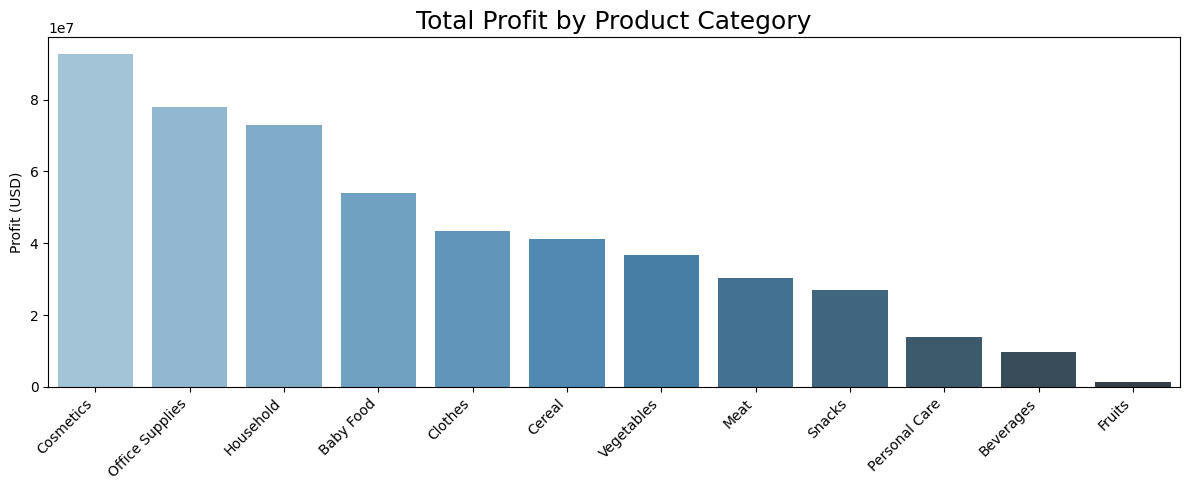

In [11]:
category_profit = df_all.groupby('item_type')['Profit'].sum()\
                        .sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=category_profit, x='item_type', y='Profit',
            hue='item_type', palette='Blues_d', legend=False)
plt.title('Total Profit by Product Category', fontsize=18)
plt.xlabel('')
plt.ylabel('Profit (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 2 - Top 10 Countries by Revenue

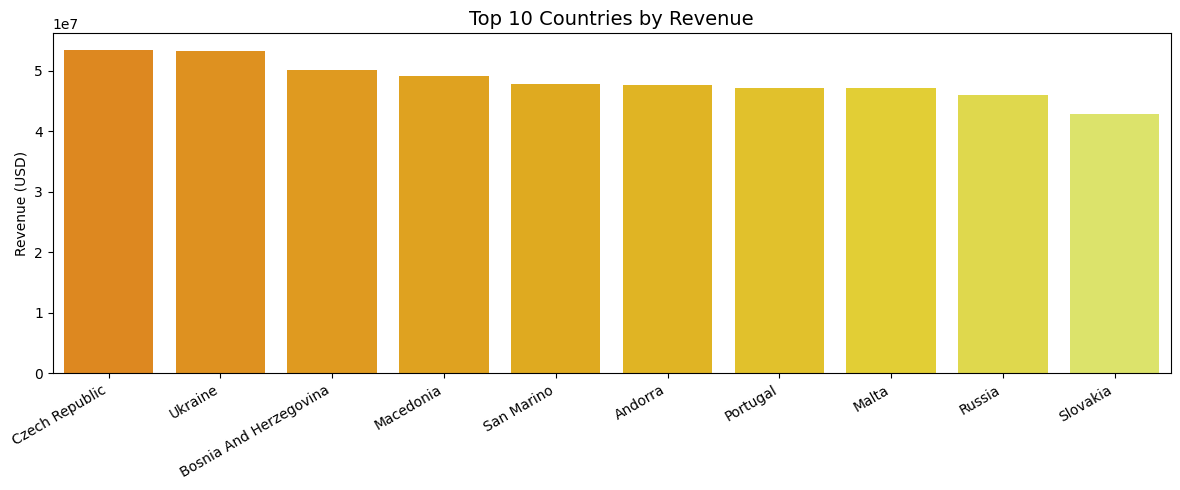

In [12]:
top_countries = df_all[df_all['name'] != 'Unknown']\
                .groupby('name')['Revenue'].sum()\
                .sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x='name', y='Revenue',
            hue='name', palette='Wistia_r', legend=False)
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Chart 3 - Revenue by Region


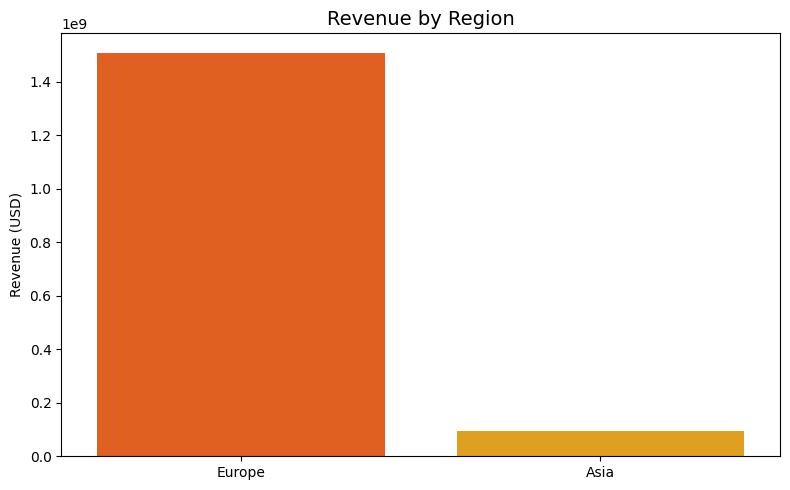

In [14]:
top_region = df_all[df_all['region'] != 'Unknown']\
             .groupby('region')['Revenue'].sum()\
             .sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_region, x='region', y='Revenue',
            hue='region', palette='autumn', legend=False)
plt.title('Revenue by Region', fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

### Chart 4 - Sales by Sales Channel

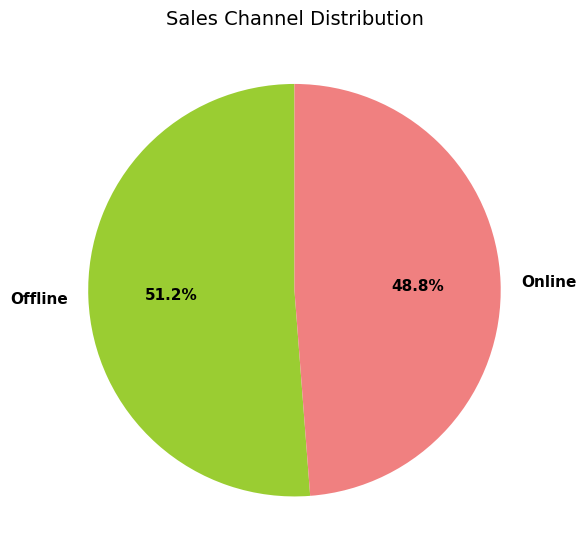

In [17]:
channel = df_all.groupby('Sales Channel')['Revenue'].sum()
colors = ['yellowgreen', 'lightcoral']

plt.figure(figsize=(6, 6), dpi=100)
plt.pie(channel, labels=channel.index, colors=colors,
        autopct='%.1f%%', startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Sales Channel Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Chart 5 - Shipping Analysis

Average Days to Ship: 24.79 days


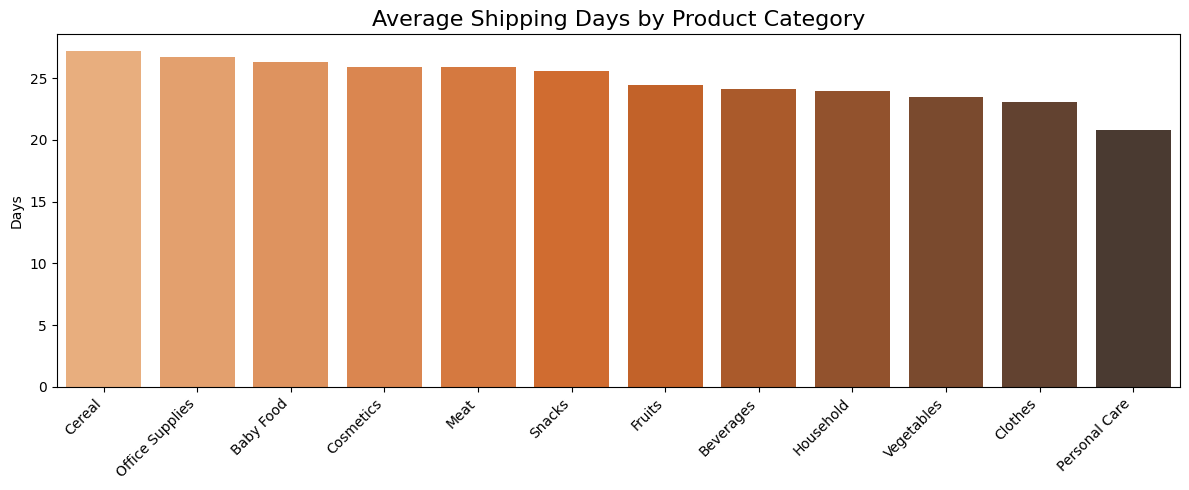

In [20]:
# Average days
print(f"Average Days to Ship: {df_all['day ship'].mean():.2f} days")

ship_cat = df_all.groupby('item_type')['day ship'].mean()\
                 .sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=ship_cat, x='item_type', y='day ship',
            hue='item_type', palette='Oranges_d', legend=False)
plt.title('Average Shipping Days by Product Category', fontsize=16)
plt.xlabel('')
plt.ylabel('Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 6 - Top 10 Slowest Countries

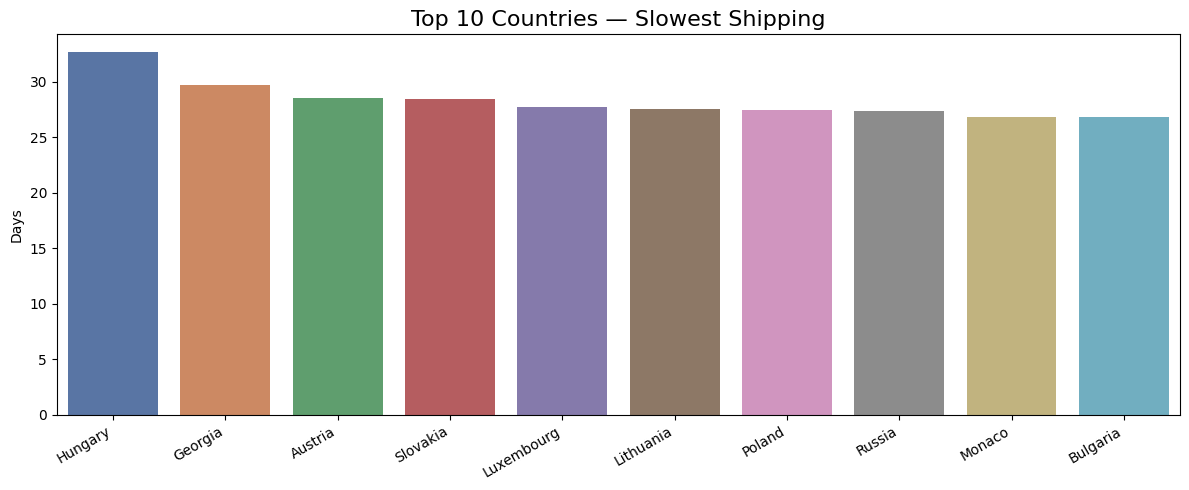

In [22]:
ship_country = df_all[df_all['name'] != 'Unknown']\
               .groupby('name')['day ship'].mean()\
               .sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=ship_country, x='name', y='day ship',
            hue='name', palette='deep', legend=False)
plt.title('Top 10 Countries — Slowest Shipping', fontsize=16)
plt.xlabel('')
plt.ylabel('Days')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Chart 7 - Shipping progress vs Profit

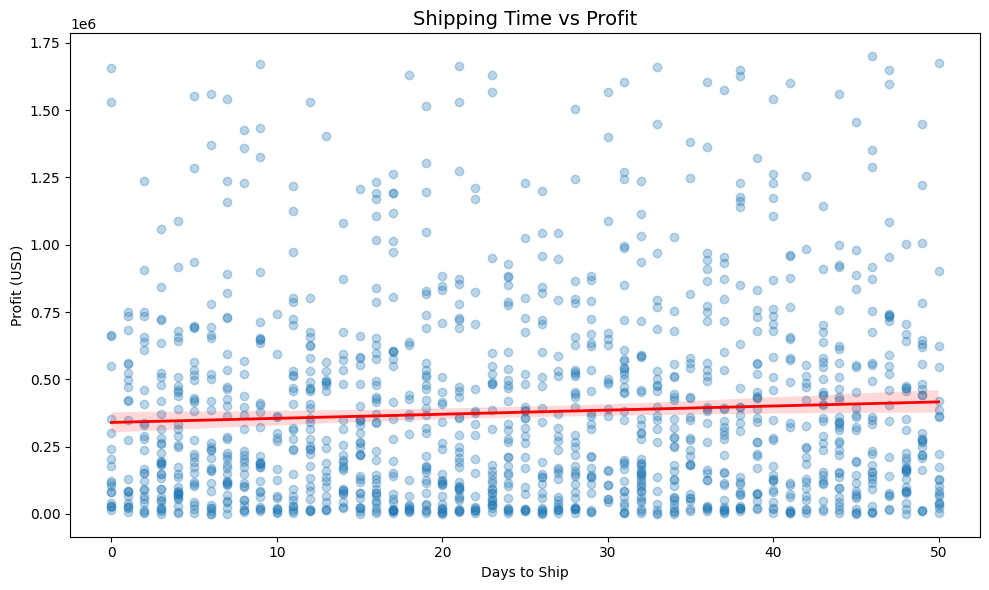

Correlation: 0.0603


In [23]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_all, x='day ship', y='Profit',
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Shipping Time vs Profit', fontsize=14)
plt.xlabel('Days to Ship')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.show()

corr = df_all['day ship'].corr(df_all['Profit'])
print(f"Correlation: {corr:.4f}")

### Chart 9 - Monthly sales trend

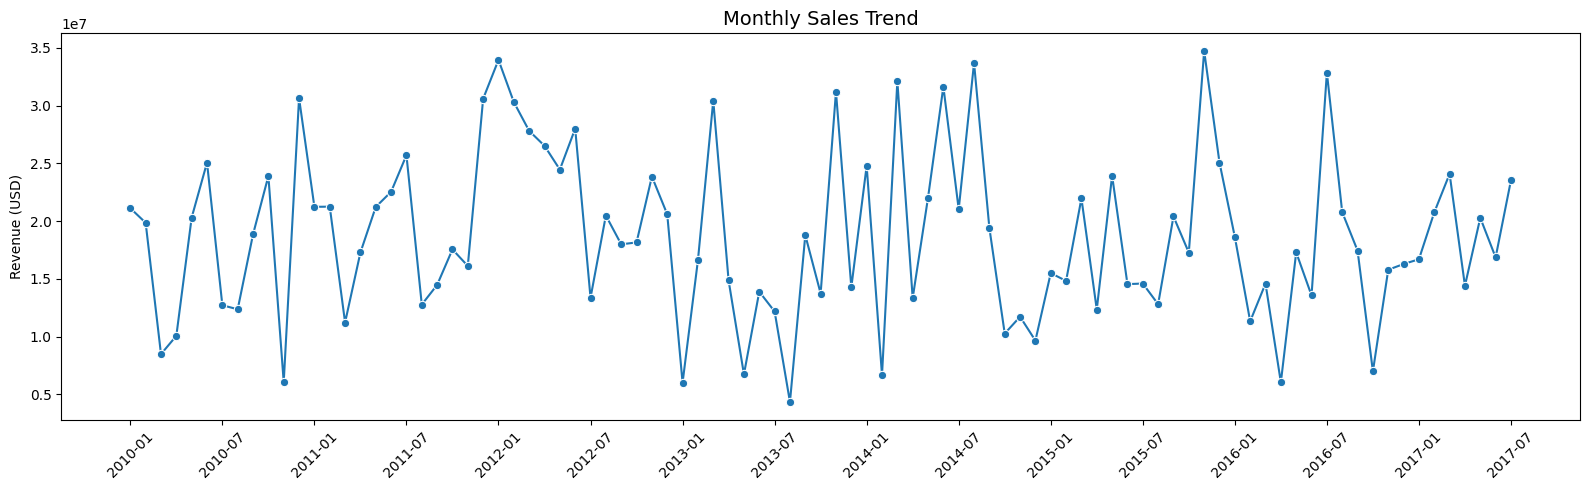

In [25]:
monthly = df_all.groupby('Month Period')['Revenue'].sum().reset_index()

plt.figure(figsize=(16, 5))
sns.lineplot(data=monthly, x='Month Period', y='Revenue', marker='o')
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(6))
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 10 - Monthly trend by category

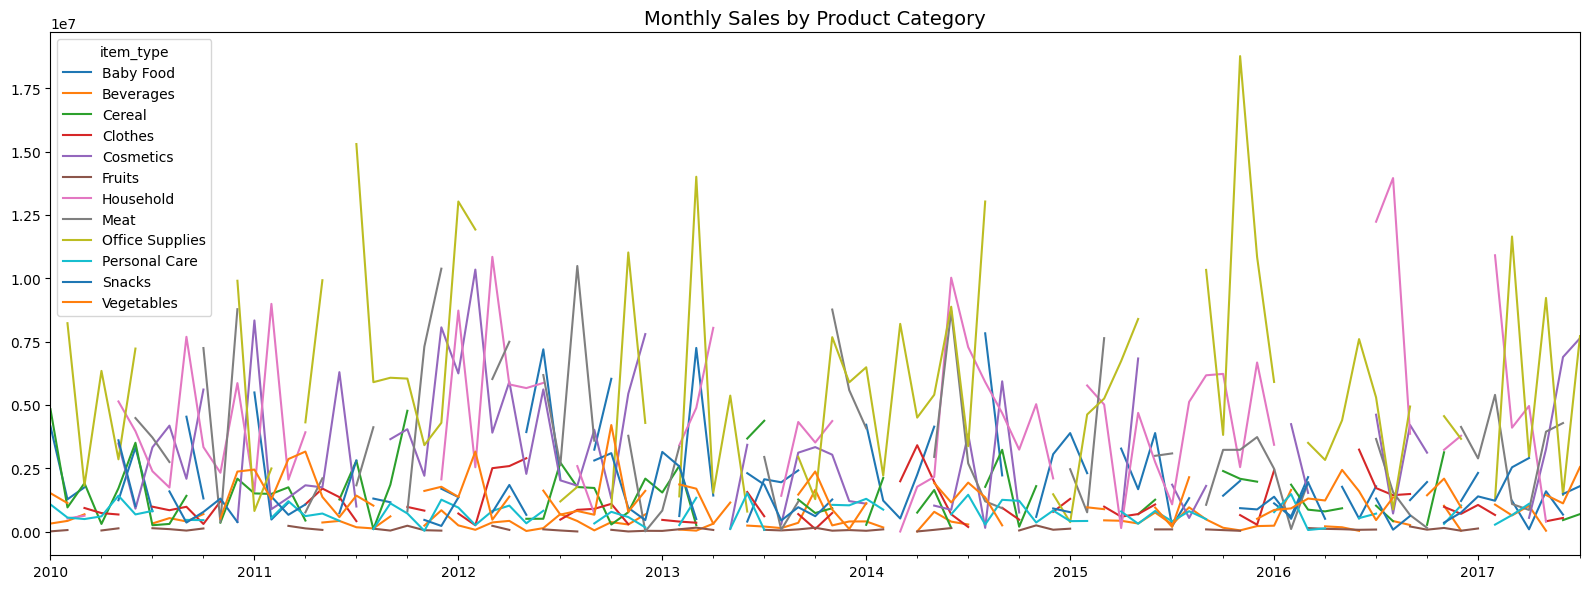

In [28]:
monthly_cat = df_all.groupby(
    [df_all['Order Date'].dt.to_period('M'), 'item_type']
)['Revenue'].sum().unstack()

monthly_cat.plot(figsize=(16, 6))
plt.title('Monthly Sales by Product Category', fontsize=14)
plt.xlabel('')
plt.tight_layout()
plt.show()

### Chart 11 - Sales by day of week

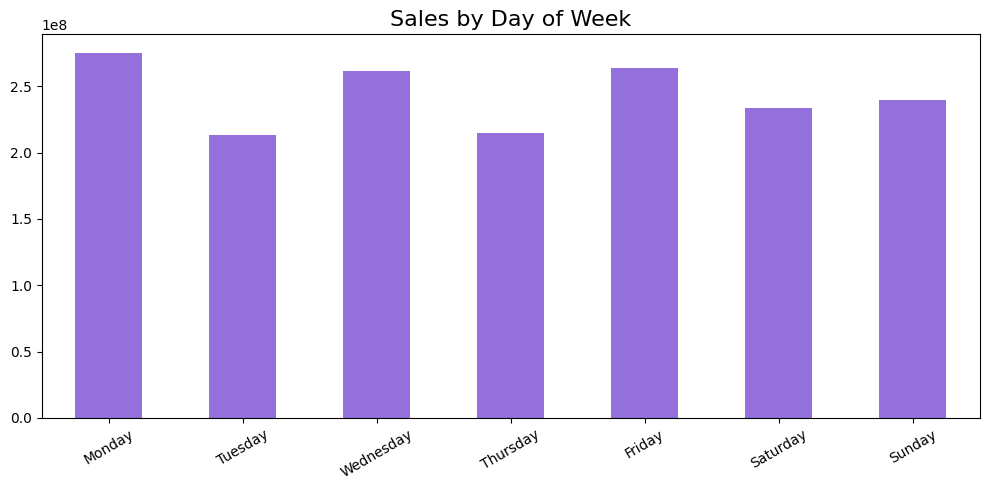

In [30]:
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_sales = df_all.groupby('Day of Week')['Revenue']\
                  .sum().reindex(day_order)

plt.figure(figsize=(10, 5))
day_sales.plot(kind='bar', color='mediumpurple')
plt.title('Sales by Day of Week', fontsize=16)
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Chart 12 - Season Analysis

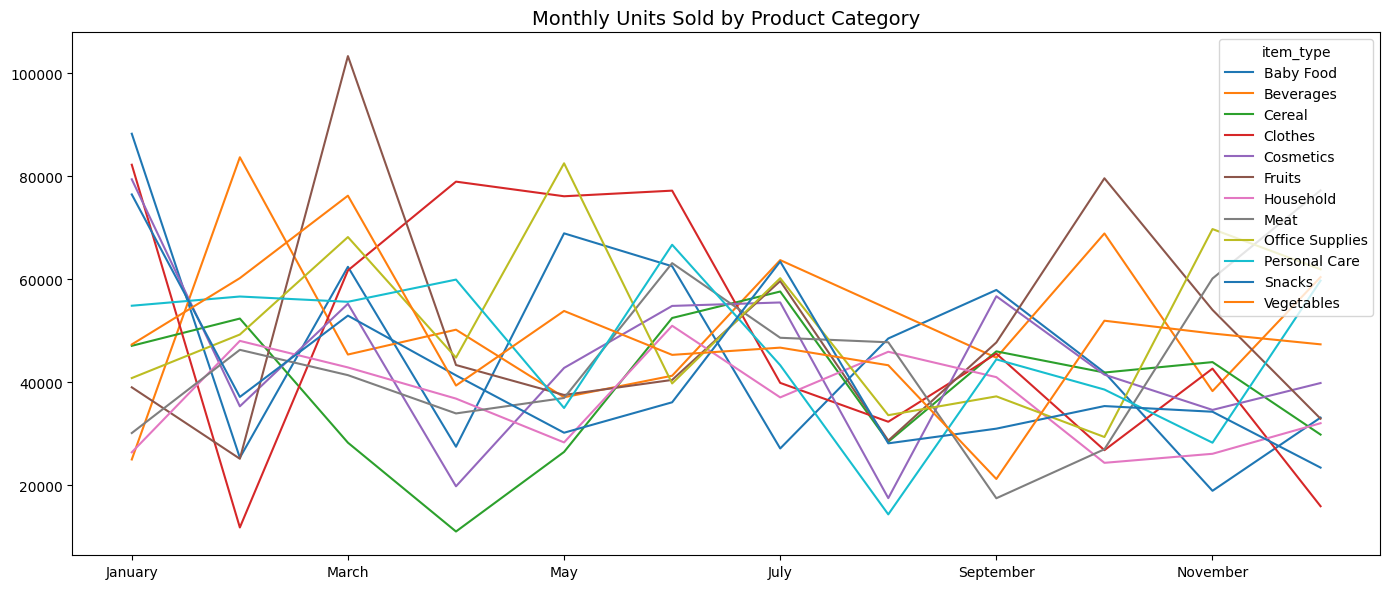

In [32]:
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

season = df_all.groupby(['Month Name', 'item_type'])['Units Sold']\
               .sum().unstack()
season = season.reindex(month_order)

season.plot(figsize=(14, 6))
plt.title('Monthly Units Sold by Product Category', fontsize=14)
plt.xlabel('')
plt.tight_layout()

plt.show()

## Conclusions & Business Insights

### 1. Product Performance
Cosmetics, Office Supplies, and Household are the
top 3 most profitable product categories, making them
the core revenue drivers of the business.
Low-performing categories should be reviewed for
pricing or cost optimization.

###2. Geographic Performance
Czech Republic is the highest revenue-contributing
country. This suggests strong market penetration
in Central Europe, which could be further leveraged
for regional expansion.

### 3. Sales Channel
Offline sales slightly dominate at 51.2% vs Online
at 48.8%. The near-equal split suggests both channels
are equally important. Investing in online growth
could tip the balance and reduce dependency on
physical sales.

### 4. Shipping Efficiency
Average shipping time is 24.79 days across all orders.
Correlation between shipping time and profit is 0.06
— indicating shipping time has minimal impact on profit.
However, reducing shipping time could improve customer
satisfaction.

### 5. Sales Trend
Monthly sales show fluctuation from 2010 to 2017
with no clear upward growth trend. This suggests
the business has reached a plateau and may need
new strategies to drive consistent growth.

### 6. Seasonal Patterns
Fruits show the strongest seasonal pattern with
notable spikes in certain months, suggesting
demand is influenced by seasonal availability.
Inventory planning for Fruits should account
for these peak periods.